In [1]:
import numpy as np
import pandas as pd
import random
import torch
#设置随机种子
def all_seed(seed):
    np.random.seed(seed)
    random.seed(seed)

    #CPU
    torch.manual_seed(seed)
    #GPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed) #当前GPU
        torch.cuda.manual_seed_all(seed) #全部GPU
    #cudnn
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = False



In [2]:
!pwd

/kaggle/working


In [3]:
!ls ../input/ml2022spring-hw4

Dataset


In [4]:
import os
import json
from pathlib import Path
#查看数据
data_dir = '../input/ml2022spring-hw4/Dataset'
#mapping.json
map_ = Path(data_dir) / 'mapping.json'
map_js = json.load(map_.open())
print('mapping.json | keys = ', map_js.keys())
# metadata.json 
metadata_ = Path(data_dir) / 'metadata.json'
metadata_js = json.load(metadata_.open())
print('matedata_js["n_mels"]=', metadata_js['n_mels'])
print(
    "metadata_js['speakers']['id00559'][:5]=", 
    metadata_js['speakers']['id00559'][:5]
)
mel = torch.load(os.path.join(data_dir, 'uttr-2918eae600684146903d49f02275cb94.pt'))
print(f'(mel_len, n_mels)={mel.shape}') 
mel

mapping.json | keys =  dict_keys(['speaker2id', 'id2speaker'])
matedata_js["n_mels"]= 40
metadata_js['speakers']['id00559'][:5]= [{'feature_path': 'uttr-2918eae600684146903d49f02275cb94.pt', 'mel_len': 397}, {'feature_path': 'uttr-ba3892259e03442a8113180f0e4630c5.pt', 'mel_len': 603}, {'feature_path': 'uttr-787eb20b357a4e2ebfb267611efbf92a.pt', 'mel_len': 584}, {'feature_path': 'uttr-863c9d7ab6bd4a70938481549e426fdc.pt', 'mel_len': 457}, {'feature_path': 'uttr-a9145f8b565f4d18894bce985b9ee3af.pt', 'mel_len': 648}]
(mel_len, n_mels)=torch.Size([397, 40])


tensor([[  5.9532,   5.7866,   4.2582,  ...,  -7.4547,  -7.9219,  -2.2850],
        [  5.6307,   4.8402,   1.5912,  ...,  -6.9332,  -7.1366,  -4.4466],
        [  5.2866,   5.0213,   2.9144,  ...,  -7.2181,  -7.3338,  -4.4947],
        ...,
        [-17.3427, -17.0293, -16.7071,  ..., -18.6104, -18.7724, -18.9308],
        [-20.7233, -20.7233, -20.7233,  ..., -20.7233, -20.7233, -20.7233],
        [-20.7233, -20.7233, -20.7233,  ..., -20.7233, -20.7233, -20.7233]])

In [5]:
metadata_path = Path(data_dir) / 'metadata.json'
metadata = json.load(metadata_path.open())['speakers']

# 打印前 1 个说话人 ID 和对应的内容
for speaker, utts in metadata.items():
    print("说话人 ID:", speaker)
    print("说话人样本数量:", len(utts))
    print("第一个样本内容:", utts[0])
    break  # 只看一个

说话人 ID: id03074
说话人样本数量: 101
第一个样本内容: {'feature_path': 'uttr-18e375195dc146fd8d14b8a322c29b90.pt', 'mel_len': 435}


In [6]:
from torch.utils.data import Dataset 



#数据集
class MyDataset(Dataset):
    def __init__(self, data_dir, segment_len=128):
        super(MyDataset, self).__init__()
        self.data_dir = data_dir
        self.segment_len = segment_len
        #加载演讲者与id编码的映射
        mapping_path = Path(data_dir) / 'mapping.json' #和os.path.join()效果一样
        mapping = json.load(mapping_path.open())
        self.speaker2id = mapping['speaker2id']

        #加载训练数据的源数据（特征文件、演讲者）
        metadata_path = Path(data_dir) / 'metadata.json'
        metadata = json.load(metadata_path.open())['speakers']

        #获取总演讲者数
        self.speaker_num = len(metadata.keys())
        self.data = []
        for speaker, utt in metadata.items():
            for utt_i in utt:
                self.data.append([utt_i['feature_path'], self.speaker2id[speaker]])
    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        feat_path, speaker = self.data[index]
        # 载入经过预处理的mel图谱特征(mel-spectrogram)
        mel = torch.load(os.path.join(self.data_dir, feat_path))
        # 分割 mel-specrogram
        if len(mel) > self.segment_len:
            start = random.randint(0, len(mel) - self.segment_len)
            # 切分语音
            mel = torch.FloatTensor(mel[start: start + self.segment_len])
        else:
            mel = torch.FloatTensor(mel)
        # 将speaker 转成long格式便于后续计算loss
        speaker = torch.FloatTensor([speaker]).long()
        return mel, speaker

    def get_speaker_number(self):
        return self.speaker_num


#推理时加载特征数据
class InferenceDataset(Dataset):
    def __init__(self, data_dir):
        super(InferenceDataset, self).__init__()
        test_path = Path(data_dir) / 'testdata.json'
        metadata = json.load(test_path.open())
        self.data_dir = data_dir
        self.data = metadata['utterances']

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        utt = self.data[index]
        feat_path = utt['feature_path']
        mel = torch.load(os.path.join(self.data_dir, feat_path))
        return feat_path, mel
        
def inference_collate_batch(batch):
    feat_path, mels = zip(*batch)
    return feat_path, torch.stack(mels)
    
                

In [7]:
import torch.nn as nn
#tranformer
class Classifier(nn.Module):
    def __init__(self, input_dim=40, d_model=80, n_spks=600, dropout=0.1):
        super(Classifier, self).__init__()
        self.pre_net = nn.Linear(input_dim, d_model)

        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model = d_model, #self_attn [Q, K, V] shape=(d_model*3, d_model)
            dim_feedforward = 256,
            nhead = 2,
            batch_first = True,
            activation = 'gelu'
        )

        self.pred_layer = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_spks)
        )

    def forward(self, mels):
        # out: (batch_size, length, d_model)
        out = self.pre_net(mels)
        out = self.encoder_layer(out)
        # mean pooling
        stats = out.mean(dim=1)
        return self.pred_layer(stats)

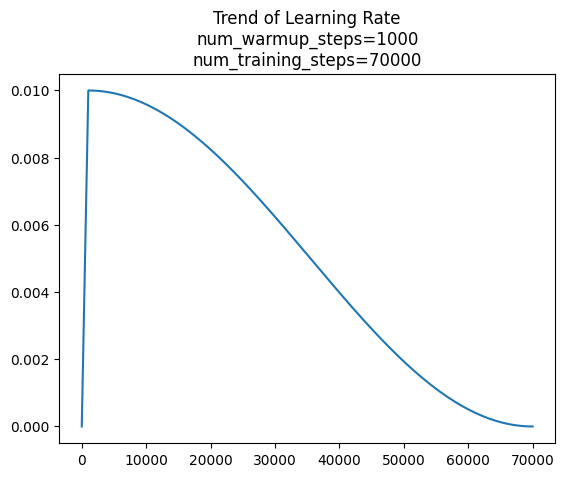

In [8]:
import matplotlib.pyplot as plt
import math
#学习率设置
def plot_lr():
    num_warmup_steps = 1000
    num_training_steps = 70000
    lr = 0.01
    res_list = []
    for current_step in range(70000):
        if current_step < num_warmup_steps:
            res = float(current_step) / float(max(1, num_warmup_steps))
            res_list.append(res * lr)
            continue
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        res = 0.5 * (1.0 + math.cos(math.pi * float(0.5) * 2.0 * progress))
        res_list.append(res * lr)

    plt.plot(res_list)
    plt.title(f'Trend of Learning Rate\nnum_warmup_steps={num_warmup_steps}\nnum_training_steps={num_training_steps}')
    plt.show()

plot_lr()

In [9]:
from torch.optim import Optimizer
from torch.optim.lr_scheduler import LambdaLR
# 学习率调度器函数
def get_cosine_schedule_with_warmup(
    opt: Optimizer,
    num_warmup_steps: int,
    num_training_steps: int,
    num_cycles: float = 0.5,
    last_epoch: int = -1
):
    def lr_lambda(current_step):
        # warmup
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        # 衰减
        progress = float(current_step - num_warmup_steps) / float(
            max(1, num_training_steps - num_warmup_steps)
        )
        return max(
            0.0, 0.5 * (1.0 + math.cos(math.pi * float(num_cycles) * 2.0 * progress))
        )
    return LambdaLR(opt, lr_lambda, last_epoch)
    

In [10]:
from tqdm import tqdm
#训练部分
def trainer(train_loader, valid_loader, model, config, device, resnet_flag=False):
    # 对于分类任务, 我们常用cross-entropy评估模型表现.
    criterion = nn.CrossEntropyLoss()
    #优化器
    optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])
    if config['scheduler_flag']:
        scheduler = get_cosine_schedule_with_warmup(optimizer, config['warmup_steps'], len(train_loader) * config['n_epochs'])

    # 模型存储位置
    save_path =  config['save_path']
    if not os.path.isdir('./models'):
        os.mkdir('./models')
    n_epochs, best_loss, step, early_stop_count = config['n_epochs'], math.inf, 0, 0
    for epoch in range(n_epochs):
        model.train()
        loss_record = []
        train_accs = []
        train_pbar = tqdm(train_loader, position=0, leave=True)

        for x, y in train_pbar:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if config['scheduler_flag']:
                scheduler.step()
            step += 1
            acc = (pred.argmax(dim = -1) == y.to(device)).float().mean()
            l_ = loss.detach().item()
            loss_record.append(l_)
            train_accs.append(acc.detach().item())
            train_pbar.set_description(f'Epoch [{epoch+1}/{n_epochs}]')
            train_pbar.set_postfix({'loss': f'{l_:.5f}', 'acc': f'{acc:.5f}'})

        mean_train_acc = sum(train_accs) / len(train_accs)
        mean_train_loss = sum(loss_record)/len(loss_record)
 

        model.eval() # 设置模型为评估模式
        loss_record = []
        test_accs = []
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            with torch.no_grad():
                pred = model(x)
                loss = criterion(pred, y)
                acc = (pred.argmax(dim=-1) == y.to(device)).float().mean()

            loss_record.append(loss.item())
            test_accs.append(acc.detach().item())
            
        mean_valid_acc = sum(test_accs) / len(test_accs)
        mean_valid_loss = sum(loss_record)/len(loss_record)
        print(f'Epoch [{epoch+1}/{n_epochs}]: Train loss: {mean_train_loss:.4f},acc: {mean_train_acc:.4f} Valid loss: {mean_valid_loss:.4f},acc: {mean_valid_acc:.4f} ')

        if mean_valid_loss < best_loss:
            best_loss = mean_valid_loss
            torch.save(model.state_dict(), save_path) # 保存最优模型
            print('Saving model with loss {:.3f}...'.format(best_loss))
            early_stop_count = 0
        else: 
            early_stop_count += 1
    
        if early_stop_count >= config['early_stop']:
            print('\nModel is not improving, so we halt the training session.')
            return

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
config = {
    'seed': 87,
    'dataset_dir': "../input/ml2022spring-hw4/Dataset",
    'n_epochs': 35,      
    'batch_size': 64, 
    
    'scheduler_flag': True,
    'valid_steps': 2000,
    'warmup_steps': 1000,
    # 'total_steps': 70000, # len(train) * n_epochs
    'learning_rate': 1e-3,          
    'early_stop': 300,
    'n_workers': 8,
    'save_path': './models/model.ckpt'
}
print(device)
all_seed(config['seed'])

cuda


In [12]:
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import random_split, DataLoader
def collate_batch(batch):
    # 将一个batch中的数据合并
    """Collate a batch of data."""
    mel, speaker = zip(*batch)
    # 为了保持一个batch内的长度都是一样的所有需要进行padding, 同时设置batch的维度是最前面的一维
    mel = pad_sequence(mel, batch_first=True, padding_value=-20)    # pad log 10^(-20) 一个很小的值
    # mel: (batch size, length, 40)
    return mel, torch.FloatTensor(speaker).long()


data_dir = config['dataset_dir']
dataset = MyDataset(data_dir)
speaker_num = dataset.get_speaker_number()
speaker2id = dataset.speaker2id
# 将数据拆分成训练集和验证集
trainlen = int(0.9 * len(dataset))
lengths = [trainlen, len(dataset) - trainlen]
trainset, validset = random_split(dataset, lengths)
testset = InferenceDataset(data_dir)

train_loader = DataLoader(
    trainset,
    batch_size=config['batch_size'],
    shuffle=True,
    drop_last=True,
    num_workers=config['n_workers'],
    pin_memory=True,
    collate_fn=collate_batch,
)

valid_loader = DataLoader(
    validset,
    batch_size=config['batch_size'],
    num_workers=config['n_workers'],
    drop_last=True,
    pin_memory=True,
    collate_fn=collate_batch,
)


test_loader = DataLoader(
    testset,
    batch_size=1,
    num_workers=config['n_workers'],
    shuffle=False,
    drop_last=False,
    pin_memory=True,
    collate_fn=inference_collate_batch,
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [13]:
model = Classifier(
    input_dim=40,  # n_mel
    d_model=80,
    n_spks=600, 
    dropout=0.1
).to(device)
trainer(train_loader, valid_loader, model, config, device)

  0%|          | 0/796 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch [1/35]: 100%|██████████| 796/796 [00:14<00:00, 53.28it/s, loss=5.06192, acc=0.09375]


Epoch [1/35]: Train loss: 5.9362,acc: 0.0146 Valid loss: 4.9711,acc: 0.0550 
Saving model with loss 4.971...


Epoch [2/35]: 100%|██████████| 796/796 [00:15<00:00, 52.80it/s, loss=3.69008, acc=0.20312]


Epoch [2/35]: Train loss: 4.4792,acc: 0.1054 Valid loss: 3.9770,acc: 0.1786 
Saving model with loss 3.977...


Epoch [3/35]: 100%|██████████| 796/796 [00:14<00:00, 54.34it/s, loss=3.14350, acc=0.31250]


...

Epoch [33/35]: Train loss: 1.6393,acc: 0.6041 Valid loss: 1.7253,acc: 0.6025 


Epoch [34/35]: 100%|██████████| 796/796 [00:15<00:00, 52.73it/s, loss=1.39414, acc=0.65625]


Epoch [34/35]: Train loss: 1.6232,acc: 0.6079 Valid loss: 1.6963,acc: 0.6197 


Epoch [35/35]: 100%|██████████| 796/796 [00:15<00:00, 51.33it/s, loss=1.63745, acc=0.59375]


Epoch [35/35]: Train loss: 1.6363,acc: 0.6041 Valid loss: 1.7151,acc: 0.6140 


In [14]:
model_best = Classifier().to(device)
model_best.load_state_dict(torch.load(config['save_path']))
model_best.eval()
mapping_path = Path(data_dir) / "mapping.json"
print(mapping_path)
mapping = json.load(mapping_path.open())
pred_id = []
pred_final_cls = []
with torch.no_grad():
    for name, data in tqdm(test_loader):
        test_pred = model_best(data.to(device))
        test_label = np.argmax(test_pred.cpu().data.numpy(), axis=1)
        pred_id += name
        pred_final_cls += [mapping["id2speaker"][str(test_label[0])]]


../input/ml2022spring-hw4/Dataset/mapping.json


100%|██████████| 8000/8000 [00:15<00:00, 520.96it/s]


In [15]:
df = pd.DataFrame()
df["Id"] = pred_id
df["Category"] = pred_final_cls
df.to_csv("submission.csv",index = False)